# Threat Scoring: Federated Autoencoder Predictions

This notebook converts actual reconstruction errors and anomaly predictions from the Federated Learning global model into a normalized threat score from 0 to 100. The score is an operational ranking aid, not a replacement for incident investigation.

Scoring uses only model outputs: normalized anomaly magnitude (60%), prediction confidence (25%), and the binary anomaly detection result (15%). The test labels and attack categories are retained for evaluation only and never contribute to the score. Severity thresholds are documented as Low (0-24), Medium (25-49), High (50-74), and Critical (75-100).

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow import keras

SEED = 42
np.random.seed(SEED)

project_root = Path.cwd().resolve()
for candidate in (project_root, project_root.parent):
    if (candidate / 'dataset' / 'UNSW-NB15').exists():
        project_root = candidate
        break

model_dir = project_root / 'models' / 'trained_models'
metrics_dir = project_root / 'results' / 'metrics'
plots_dir = project_root / 'results' / 'plots'
metrics_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

data_dir = project_root / 'dataset' / 'UNSW-NB15'
model_path = model_dir / 'federated_autoencoder_model.h5'
pipeline_path = project_root / 'models' / 'preprocessing_pipeline.pkl'
metadata_path = model_dir / 'federated_autoencoder_metadata.pkl'
for required_path in (model_path, pipeline_path, metadata_path):
    if not required_path.exists():
        raise FileNotFoundError(f'Missing required artifact: {required_path}')

train_df = pd.read_csv(data_dir / 'UNSW_NB15_training-set.csv')
test_df = pd.read_csv(data_dir / 'UNSW_NB15_testing-set.csv')
with pipeline_path.open('rb') as file:
    preprocessor = pickle.load(file)
with metadata_path.open('rb') as file:
    model_metadata = pickle.load(file)
global_model = keras.models.load_model(model_path, compile=False)

feature_cols = [column for column in train_df.columns if column not in ('label', 'attack_cat')]
X_test = np.asarray(preprocessor.transform(test_df[feature_cols]), dtype=np.float32)
y_test = test_df['label'].astype(int).to_numpy()
threshold = float(model_metadata['anomaly_threshold'])
print(f'Loaded federated model; test rows={len(X_test)}; threshold={threshold:.6f}')

Loaded federated model; test rows=82332; threshold=0.031196


In [2]:
def reconstruction_errors(features):
    reconstructed = global_model.predict(features, batch_size=1024, verbose=0)
    return np.mean(np.square(features - reconstructed), axis=1)


def severity_for_score(score):
    if score < 25:
        return 'Low'
    if score < 50:
        return 'Medium'
    if score < 75:
        return 'High'
    return 'Critical'


reconstruction_error = reconstruction_errors(X_test)
predicted_anomaly = (reconstruction_error > threshold).astype(int)

# Confidence is the distance from the decision boundary, expressed between 0 and 1.
# It is calculated from the model score only, not from the test labels.
anomaly_magnitude = np.clip(reconstruction_error / (2 * threshold), 0, 1)
confidence = np.where(
    predicted_anomaly == 1,
    np.clip(reconstruction_error / threshold - 1, 0, 1),
    np.clip(1 - reconstruction_error / threshold, 0, 1),
)

# Weighted score: anomaly magnitude 60%, confidence 25%, detection result 15%.
threat_score = np.clip(
    100 * (0.60 * anomaly_magnitude + 0.25 * confidence + 0.15 * predicted_anomaly),
    0,
    100,
)
severity = np.array([severity_for_score(score) for score in threat_score])

# Attack labels/categories are evaluation context only and do not enter scoring.
events = pd.DataFrame({
    'event_id': np.arange(len(test_df)),
    'attack_cat_for_evaluation': test_df['attack_cat'].fillna('Unknown').astype(str),
    'true_label_for_evaluation': y_test,
    'reconstruction_error': reconstruction_error,
    'anomaly_threshold': threshold,
    'predicted_anomaly': predicted_anomaly,
    'model_confidence': confidence,
    'anomaly_magnitude': anomaly_magnitude,
    'threat_score': threat_score,
    'severity': severity,
})
events = events.sort_values('threat_score', ascending=False).reset_index(drop=True)
events.to_csv(metrics_dir / '07_threat_scored_events.csv', index=False)
print(events.head(10).to_string(index=False))
print('\nSeverity counts:')
print(events['severity'].value_counts().reindex(['Low', 'Medium', 'High', 'Critical'], fill_value=0).to_string())

 event_id attack_cat_for_evaluation  true_label_for_evaluation  reconstruction_error  anomaly_threshold  predicted_anomaly  model_confidence  anomaly_magnitude  threat_score severity
    82087                    Normal                          0              0.063577           0.031196                  1               1.0                1.0         100.0 Critical
    82315                    Normal                          0              0.095197           0.031196                  1               1.0                1.0         100.0 Critical
    82321                    Normal                          0              0.095198           0.031196                  1               1.0                1.0         100.0 Critical
    18676                   Generic                          1              0.075970           0.031196                  1               1.0                1.0         100.0 Critical
    18674                   Generic                          1              0.090295 

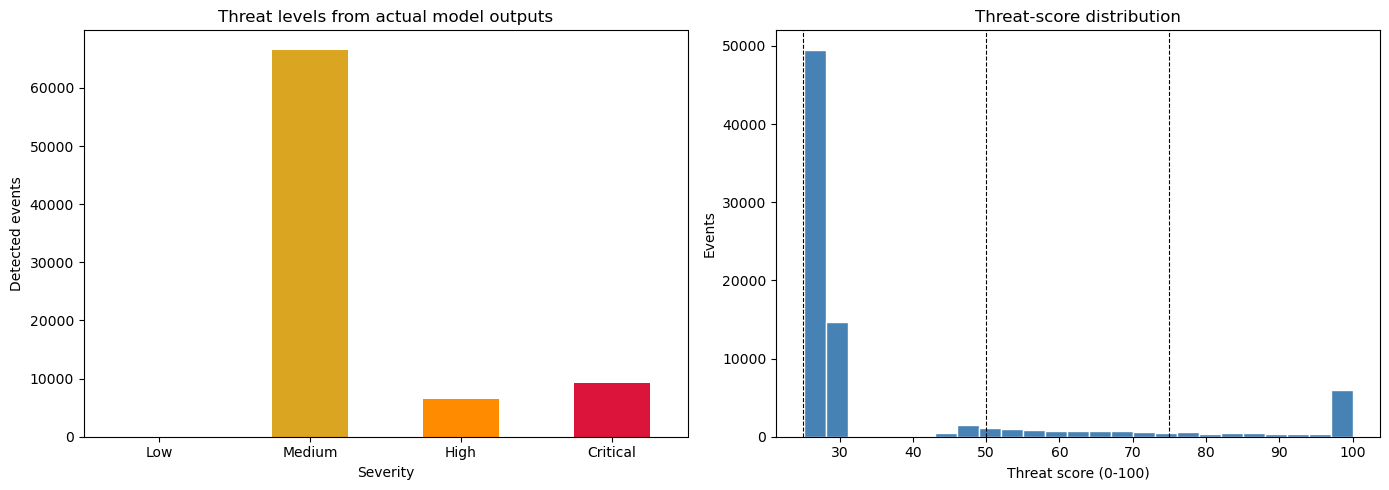

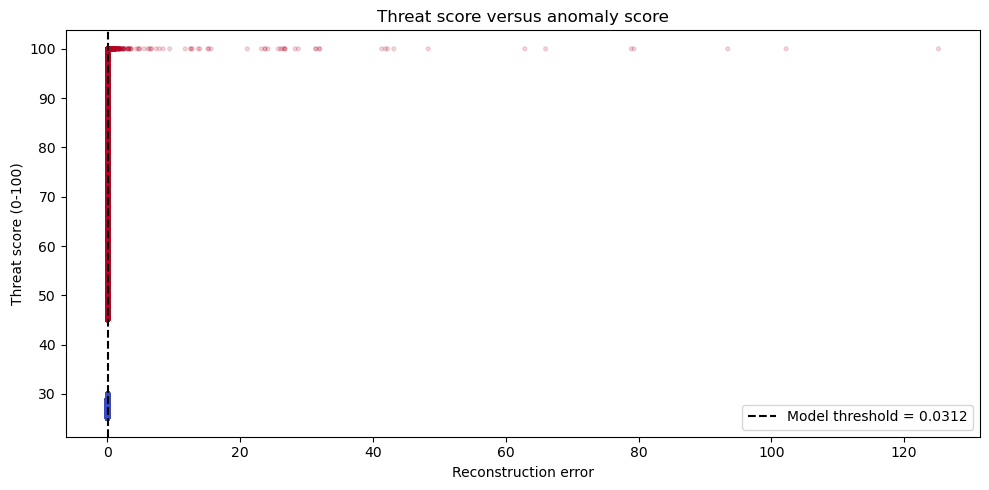

Metrics saved to C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\results\metrics
Plots saved to C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\results\plots


In [3]:
severity_order = ['Low', 'Medium', 'High', 'Critical']
severity_counts = events['severity'].value_counts().reindex(severity_order, fill_value=0)

# These metrics describe the real model decisions and score distribution; labels are not score inputs.
evaluation_metrics = {
    'event_count': int(len(events)),
    'detected_anomaly_count': int(events['predicted_anomaly'].sum()),
    'mean_threat_score': float(events['threat_score'].mean()),
    'median_threat_score': float(events['threat_score'].median()),
    'max_threat_score': float(events['threat_score'].max()),
    'low_count': int(severity_counts['Low']),
    'medium_count': int(severity_counts['Medium']),
    'high_count': int(severity_counts['High']),
    'critical_count': int(severity_counts['Critical']),
    'threshold': threshold,
    'score_weights': {
        'anomaly_magnitude': 0.60,
        'model_confidence': 0.25,
        'predicted_anomaly': 0.15,
    },
    'severity_thresholds': {
        'Low': '0-24',
        'Medium': '25-49',
        'High': '50-74',
        'Critical': '75-100',
    },
}
pd.DataFrame([evaluation_metrics]).drop(columns=['score_weights', 'severity_thresholds']).to_csv(
    metrics_dir / '07_threat_scoring_metrics.csv', index=False
)
with (metrics_dir / '07_threat_scoring_config.json').open('w', encoding='utf-8') as file:
    import json
    json.dump(evaluation_metrics, file, indent=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
severity_counts.plot(kind='bar', color=['seagreen', 'goldenrod', 'darkorange', 'crimson'], ax=axes[0])
axes[0].set(xlabel='Severity', ylabel='Detected events', title='Threat levels from actual model outputs')
axes[0].tick_params(axis='x', rotation=0)
axes[1].hist(events['threat_score'], bins=25, color='steelblue', edgecolor='white')
for boundary in (25, 50, 75):
    axes[1].axvline(boundary, color='black', linestyle='--', linewidth=0.8)
axes[1].set(xlabel='Threat score (0-100)', ylabel='Events', title='Threat-score distribution')
fig.tight_layout()
fig.savefig(plots_dir / '07_threat_scoring_overview.png', dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(events['reconstruction_error'], events['threat_score'], alpha=0.15, s=8, c=events['predicted_anomaly'], cmap='coolwarm')
ax.axvline(threshold, color='black', linestyle='--', label=f'Model threshold = {threshold:.4f}')
ax.set(xlabel='Reconstruction error', ylabel='Threat score (0-100)', title='Threat score versus anomaly score')
ax.legend()
fig.tight_layout()
fig.savefig(plots_dir / '07_threat_score_vs_reconstruction_error.png', dpi=200)
plt.show()

print(f'Metrics saved to {metrics_dir}')
print(f'Plots saved to {plots_dir}')